In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

from dadapy import DiffImbalance
import matplotlib.pyplot as plt
import numpy as np
import os
import jax

jax.config.update("jax_platform_name", "gpu")  # can run on 'cpu' or 'gpu'; restart the
                                               # notebook kernel to make this change effective
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"  # avoid jax memory preallocation

os.environ["CUDA_VISIBLE_DEVICES"] = '1' 

%matplotlib inline
%load_ext autoreload
%autoreload 2

two_pi = 2*np.pi

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
def check_for_equal_rows(matrix):
    for i in range(len(matrix)):
        for j in range(i + 1, len(matrix)):
            if np.array_equal(matrix[i], matrix[j]):
                print(f"Equal rows found: {i} and {j}")
                return True
    return False


# Example matrix
matrix = np.random.rand(5, 3)
print(check_for_equal_rows(matrix))
matrix = np.zeros((5, 3))
print(check_for_equal_rows(matrix))

False
Equal rows found: 0 and 1
True


## Load the trajectories and standardize the data before doing IIB

In [9]:
dihedral = np.loadtxt("./traj_data/dihedral_angle_S1.txt")

pyramidalization = np.loadtxt("./traj_data/pyramidalization_S1.txt")

bond = np.loadtxt("./traj_data/bond_distance_S1.txt")

delta_E = np.loadtxt("./traj_data/EneGap_S1.txt")

print(dihedral.shape, bond.shape, pyramidalization.shape, delta_E.shape)

## in eV
print(delta_E.min(), delta_E.max())

## in Angstrom
print(bond.min(), bond.max())

print("==============================")
## in degrees converted to radians
print(pyramidalization.min(), pyramidalization.max())
pyramidalization = np.mod(np.deg2rad(pyramidalization), two_pi)
print(pyramidalization.min(), pyramidalization.max(), two_pi - pyramidalization.max())

print("==============================")
## convert to (0,2*pi)
print(dihedral.min(), dihedral.max())
dihedral = np.mod(np.deg2rad(dihedral), two_pi)
print(dihedral.min(), dihedral.max(), two_pi - dihedral.max())

(234664, 2) (234664, 2) (234664, 2) (234664,)
0.0011790690000452742 3.746417613999938
0.0 853.5
-25.091784 853.5
0.0 6.283175184269925 1.0122909661625101e-05
0.0 853.5
0.0 6.274458660919615 0.008726646259971105


In [ ]:
frame_stride = 20

all_modes = np.column_stack(
    (
        dihedral[::frame_stride, 1],
        bond[::frame_stride, 1],
        pyramidalization[::frame_stride, 1],
    )
)
delta_E = delta_E[::frame_stride]


print(all_modes.shape, delta_E.shape)

(11734, 3) (11734,)


In [11]:
print(all_modes[:5])

[[3.14 1.36 6.13]
 [3.14 1.45 6.08]
 [3.11 1.38 6.03]
 [3.11 1.46 6.05]
 [3.02 1.41 6.11]]


# S1 - full space

In [12]:
data_A = all_modes
data_B = all_modes
periods_A = np.array([two_pi, 0, two_pi])
seed_val = 0
print(data_A.shape, data_B.shape)
np.random.seed(seed_val)

# train the DII to recover ground-truth metric
dii = DiffImbalance(
    data_A=data_A,  # matrix of shape (N,D_A)
    data_B=data_B,  # matrix of shape (N,D_B)
    periods_A=periods_A,
    periods_B=periods_A,
    seed=seed_val,
    num_epochs=100,
    batches_per_epoch=1,  # no mini-batches
    l1_strength=0.0,  # no l1 regularization
    point_adapt_lambda=True,
    k_init=100,
    k_final=100,
    lambda_factor=0.1,
    params_init=None,  # automatically set to [0.1,0.1,0.1,0.1,0.1]
    optimizer_name="adam",  # possible choices: "sgd", "adam", "adamw"
    learning_rate=1e-2,
    learning_rate_decay=None,  # possible choices: None, "cos", "exp"
    num_points_rows=None,
)
weights, imbs = dii.train()

(11734, 3) (11734, 3)


Training:   0%|          | 0/100 [00:00<?, ?it/s]

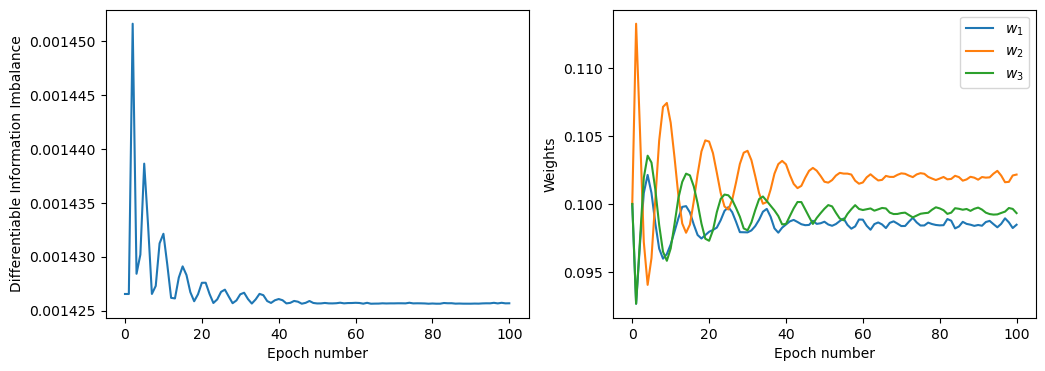

Optimal DII over full data set: 0.001426


In [13]:
# plot the DII and the weights during the training
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(imbs)
ax2.plot(weights[:, 0], label="$w_1$")
ax2.plot(weights[:, 1], label="$w_2$")
ax2.plot(weights[:, 2], label="$w_3$")

ax1.set(ylabel="Differentiable Information Imbalance", xlabel="Epoch number")
ax2.set(ylabel="Weights", xlabel="Epoch number")
ax2.legend()
plt.show()

imb_final, _ = dii.return_final_dii(
    compute_error=False, ratio_rows_columns=None, seed=0, discard_close_ind=0
)
print(f"Optimal DII over full data set: {imb_final:2f}")  # can also be accessed

In [14]:
# forward greedy search
(
    feature_sets_fw_all,
    diis_fw_all,
    errors_fw_all,
    weights_fw_all,
) = dii.forward_greedy_feature_selection(
    n_features_max=3,
    n_best=3,
    compute_error=True,
    ratio_rows_columns=1,
    seed=seed_val,
    discard_close_ind=0,
)

diis_fw_all_array = np.array(diis_fw_all)

Training:   0%|          | 0/100 [00:00<?, ?it/s]

Feature set = [0], DII = 0.1147872656583786



Training:   0%|          | 0/100 [00:00<?, ?it/s]

Feature set = [1], DII = 0.9414300918579102



Training:   0%|          | 0/100 [00:00<?, ?it/s]

...


Optimal weights for feature set [0, 2]: [0.1 0.  0.1]

------------------------------------------------
Best 2-tuple: [0, 2]
	DII: 0.027301818132400513
	Optimal weights: [0.1 0.  0.1]
Selected 3 best candidates for next iteration
------------------------------------------------


Training:   0%|          | 0/100 [00:00<?, ?it/s]

Feature set = [0, 1, 2], DII = 0.0029362409841269255



Training:   0%|          | 0/100 [00:00<?, ?it/s]


Optimal weights for feature set [0, 1, 2]: [0.1 0.1 0.1]

------------------------------------------------
Best 3-tuple: [0, 1, 2]
	DII: 0.0029362409841269255
	Optimal weights: [0.1 0.1 0.1]
Selected 1 best candidates for next iteration
------------------------------------------------


In [15]:
print(f"\nSelected feature subsets:\n {feature_sets_fw_all}\n")
print("Forward DIIs:", diis_fw_all)
print("Forward Errors:", errors_fw_all)
print("Forward Weights:", weights_fw_all)


Selected feature subsets:
 [[0], [0, 2], [0, 1, 2]]

Forward DIIs: [0.1147872656583786, 0.027301818132400513, 0.0029362409841269255]
Forward Errors: [0.0006700304220430553, 0.00026279932353645563, 6.204062174219871e-06]
Forward Weights: [array([0.1, 0. , 0. ]), array([0.1, 0. , 0.1], dtype=float32), array([0.1, 0.1, 0.1], dtype=float32)]


# S1 - dE

In [16]:
data_A = all_modes
data_B = delta_E[:, np.newaxis]
seed_val = 42
print(data_A.shape, data_B.shape)
np.random.seed(seed_val)

# train the DII to recover ground-truth metric
dii = DiffImbalance(
    data_A=data_A,  # matrix of shape (N,D_A)
    data_B=data_B,  # matrix of shape (N,D_B)
    periods_A=periods_A,
    periods_B=None,
    seed=seed_val,
    num_epochs=100,
    batches_per_epoch=1,  # no mini-batches
    l1_strength=0.0,  # no l1 regularization
    point_adapt_lambda=True,
    k_init=100,
    k_final=100,
    lambda_factor=0.1,
    params_init=None,  # automatically set to [0.1,0.1,0.1,0.1,0.1]
    optimizer_name="adam",  # possible choices: "sgd", "adam", "adamw"
    learning_rate=1e-2,
    learning_rate_decay=None,  # possible choices: None, "cos", "exp"
    num_points_rows=None,
)
weights, imbs = dii.train()

(11734, 3) (11734, 1)


Training:   0%|          | 0/100 [00:00<?, ?it/s]

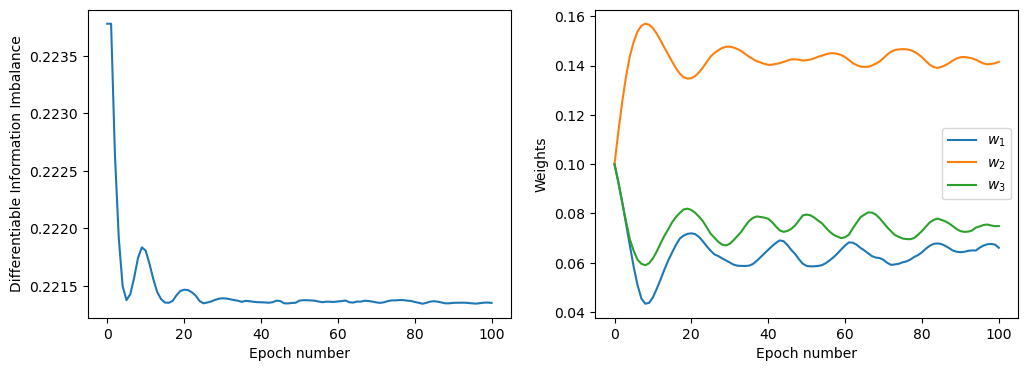

Optimal DII over full data set: 0.221347


In [17]:
# plot the DII and the weights during the training
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(imbs)
ax2.plot(weights[:, 0], label="$w_1$")
ax2.plot(weights[:, 1], label="$w_2$")
ax2.plot(weights[:, 2], label="$w_3$")

ax1.set(ylabel="Differentiable Information Imbalance", xlabel="Epoch number")
ax2.set(ylabel="Weights", xlabel="Epoch number")
ax2.legend()
plt.show()

imb_final, _ = dii.return_final_dii(
    compute_error=False, ratio_rows_columns=None, seed=0, discard_close_ind=0
)
print(f"Optimal DII over full data set: {imb_final:2f}")  # can also be accessed

In [18]:
imb_final, _ = dii.return_final_dii(
    compute_error=False, ratio_rows_columns=None, seed=0, discard_close_ind=0
)
print(f"Optimal DII over full data set: {imb_final:2f}")  # can also be accessed

final_weights = weights[-1]
print(final_weights)

Optimal DII over full data set: 0.221347
[0.07 0.14 0.07]


In [19]:
# forward greedy search
(
    feature_sets_fw_dE,
    diis_fw_dE,
    errors_fw_dE,
    weights_fw_dE,
) = dii.forward_greedy_feature_selection(
    n_features_max=3,
    n_best=3,
    compute_error=True,
    ratio_rows_columns=1,
    seed=seed_val,
    discard_close_ind=0,
)

diis_fw_dE_array = np.array(diis_fw_dE)

Training:   0%|          | 0/100 [00:00<?, ?it/s]

Feature set = [0], DII = 0.35252058506011963



Training:   0%|          | 0/100 [00:00<?, ?it/s]

Feature set = [1], DII = 0.9258277416229248



Training:   0%|          | 0/100 [00:00<?, ?it/s]

...


Optimal weights for feature set [0, 1]: [0.06 0.13 0.  ]

------------------------------------------------
Best 2-tuple: [0, 1]
	DII: 0.272216796875
	Optimal weights: [0.06 0.13 0.  ]
Selected 3 best candidates for next iteration
------------------------------------------------


Training:   0%|          | 0/100 [00:00<?, ?it/s]

Feature set = [0, 1, 2], DII = 0.2265496551990509



Training:   0%|          | 0/100 [00:00<?, ?it/s]


Optimal weights for feature set [0, 1, 2]: [0.07 0.14 0.07]

------------------------------------------------
Best 3-tuple: [0, 1, 2]
	DII: 0.2265496551990509
	Optimal weights: [0.07 0.14 0.07]
Selected 1 best candidates for next iteration
------------------------------------------------


In [20]:
print(f"\nSelected feature subsets:\n {feature_sets_fw_dE}\n")
print("Forward DIIs:", diis_fw_dE)
print("Forward Errors:", errors_fw_dE)
print("Forward Weights:", weights_fw_dE)


Selected feature subsets:
 [[0], [0, 1], [0, 1, 2]]

Forward DIIs: [0.35252058506011963, 0.272216796875, 0.2265496551990509]
Forward Errors: [0.0023710541427135468, 0.002009748248383403, 0.0017081697005778551]
Forward Weights: [array([0.1, 0. , 0. ]), array([0.06, 0.13, 0.  ], dtype=float32), array([0.07, 0.14, 0.07], dtype=float32)]
